# Web3 Python 100本ノック：第1章
## §1-6：有名NFTの「現在の所有者」を特定せよ

世間では「NFT＝デジタル画像」と思われがちですが、web3開発者の視点から見るとそれは不正確です。<br>
NFTの正体は、USDTなどのトークンと同じように**「スマートコントラクト上に記録された単なる台帳（誰が何番のトークンを持っているかのリスト）」**に過ぎません。

このノートでは、NFTの標準規格である「ERC721」のスマートコントラクトと対話し、<br>
世界で最も有名なNFTの一つである「Bored Ape Yacht Club (BAYC)」の特定のID（#1）を、現在どのアドレスが所有しているかを突き止めます。

> **注意**: 各セルを順番に実行してください。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tsukumo-999/web3-knock100-first-half/blob/master/s1-6_nft_owner.ipynb)

サンプルとして所有者を調査する対象のNFT Bored Ape Yacht Club (BAYC) #1
[OpenSea](https://opensea.io/item/ethereum/0xbc4ca0eda7647a8ab7c2061c2e118a18a936f13d/1)
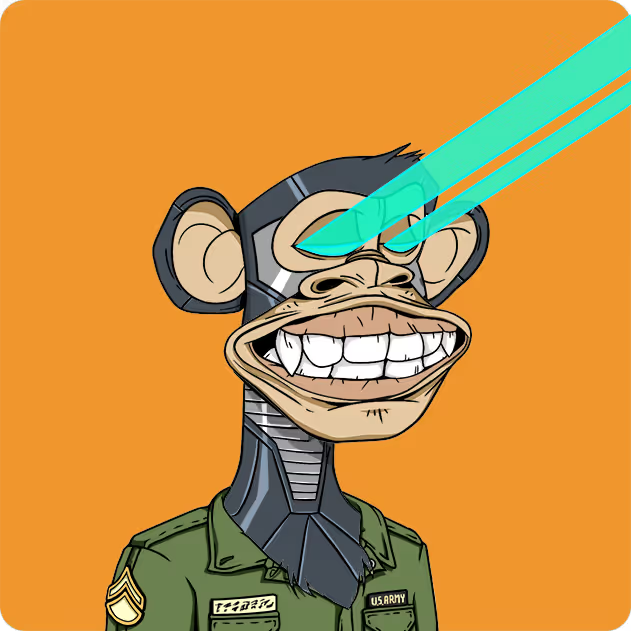

In [6]:
#!pip install web3==7.16.0

## ERC721の最小ABI

§1-2でUSDTの残高を調べた際、`balanceOf` という関数をABIに定義しました。
NFT（ERC721規格）の場合は、誰が持っているかを調べるために **`ownerOf(tokenId)`** という関数が標準で用意されています。今回もこの関数だけを最小限のABIとして定義して呼び出します。

### 1. 接続設定

In [7]:
from web3 import Web3


# 1. 接続設定
RPC_URL = "https://eth.drpc.org"
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
w3 = Web3(Web3.HTTPProvider(RPC_URL, request_kwargs={'headers': headers, 'timeout': 5}))


### 2. NFT所有者追跡

In [8]:
# 2. BAYC (Bored Ape Yacht Club) のコントラクトアドレス
BAYC_ADDRESS = "0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D"
contract_address = w3.to_checksum_address(BAYC_ADDRESS)

# 3. 最小限のABI定義（今回は ownerOf だけを定義）
erc721_abi = [
    {
        "inputs": [{"internalType": "uint256", "name": "tokenId", "type": "uint256"}],
        "name": "ownerOf",
        "outputs": [{"internalType": "address", "name": "", "type": "address"}],
        "stateMutability": "view",
        "type": "function"
    }
]

# 4. コントラクトのインスタンス化
bayc_contract = w3.eth.contract(address=contract_address, abi=erc721_abi)

In [9]:
# 5. 所有者を調べたいToken ID（ここでは #1 番のサルのNFTを指定していますがここを変えることでidを変更できます）
token_id = 1

try:
    # コントラクトの ownerOf 関数を呼び出し、引数にToken IDを渡す
    owner_address = bayc_contract.functions.ownerOf(token_id).call()
    
    print("取得成功！")
    print("-" * 40)
    print(f"コレクション: Bored Ape Yacht Club (BAYC)")
    print(f"Token ID   : #{token_id}")
    print(f"現在の所有者: {owner_address}")
    print("-" * 40)
    
except Exception as e:
    print(f"エラーが発生しました: {e}")

取得成功！
----------------------------------------
コレクション: Bored Ape Yacht Club (BAYC)
Token ID   : #1
現在の所有者: 0x46EFbAedc92067E6d60E84ED6395099723252496
----------------------------------------


実行すると現在の所有者を確認することができます。(2026/08時点)

```
 ----------------------------------------
 コレクション: Bored Ape Yacht Club (BAYC)
 Token ID   : #1
 現在の所有者: 0x46EFbAedc92067E6d60E84ED6395099723252496
 ----------------------------------------
```

### おまけ：OpenSeaで実際のNFTを確認する 
addressだけだと、元のNFT本体がどんなもの(画像なのか文章なのか等)なのか分からないので、マーケットプレイスで確認します


In [11]:
from IPython.display import display, HTML
print("スマートコントラクト上のデータが、実際のマーケットプレイスでどう見えるか確認しましょう。")

# OpenSeaのURLは「/assets/チェーン名/コントラクトアドレス/トークンID」という規則で作られています
opensea_url = f"https://opensea.io/assets/ethereum/{contract_address}/{token_id}"

print(f"URL: {opensea_url}\n")

# Jupyter Notebookの機能を使い、クリック可能なリッチなリンクを生成して表示
html_link = f'''
<a href="{opensea_url}" target="_blank" style="
    display: inline-block;
    padding: 10px 20px;
    background-color: #2081E2;
    color: white;
    text-decoration: none;
    font-weight: bold;
    border-radius: 5px;
">
     OpenSeaで BAYC #{token_id} を見る
</a>
'''
display(HTML(html_link))

スマートコントラクト上のデータが、実際のマーケットプレイスでどう見えるか確認しましょう。
URL: https://opensea.io/assets/ethereum/0xBC4CA0EdA7647A8aB7C2061c2E118A18a936f13D/1

